In [1]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon, chisquare, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns56
import traceback
import colorsys
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'

CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_COLOR_DESAT = '#D98C90'
CR_COLOR_DESAT = '#A0A0A0'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#DEB9E0','#B78AB9','#906D92','#ABC5E8','#869BB7','#5E6C80']#,'#6ded94','#50d979','#36bf5f']

dualanimalnames = ['BS_40','BS_41','BS_42','BS_49','BS_50','BS_51','BS_56','BS_59','BS_67','BS_70','BS_72','BS_87','BS_108','DS_15','DS_19']


def hex_to_rgb(value):
    value = value.lstrip('#')
    lv = len(value)
    return tuple(int(value[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))

def rgb_to_hex(rgb):
    return '#%02x%02x%02x' % rgb

def dark(chex,val=0.2):
    crgb = np.array(hex_to_rgb(chex)) / 255
    hsv = np.array(colorsys.rgb_to_hsv(crgb[0],crgb[1],crgb[2]))
    hsv[2] -= val
    crgb = np.array(colorsys.hsv_to_rgb(hsv[0],hsv[1],hsv[2]))*255
    crgb = np.array(crgb,dtype=int)
    hex = rgb_to_hex(tuple(crgb))
    return hex

In [2]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 2n.csv'))

In [4]:
df

,Unnamed: 0,session,cluster,phase,mean_hit,mean_miss,ps_hm,mean_go,mean_nogo,ps_tot,mean_falarm,mean_creject,ps_fc
0,0,BS_49_10_AC.pickle,12,pre late,0.012500,0.013953,0.852843,0.009150,0.011828,0.576884,0.004615,0.010000,0.322095
1,1,DS_19_14_AC.pickle,3,post expert,0.067717,0.027273,0.203535,0.060825,0.061538,0.959536,0.047761,0.067164,0.302691
2,2,DS_19_14_AC.pickle,15,post expert,0.023077,NaN,NaN,0.018519,0.025000,0.768872,0.014286,0.025000,0.636650
3,3,DS_19_14_AC.pickle,19,post expert,0.337795,0.118182,0.000013,0.382474,0.375641,0.757538,0.467164,0.417910,0.040509
4,4,DS_19_14_AC.pickle,46,post expert,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1824,1824,DS_15_3_AC.pickle,92,post early,0.037063,0.045455,0.829188,0.032639,0.033333,0.979621,0.028276,0.000000,0.454657
1825,1825,DS_15_3_AC.pickle,95,post early,0.061538,0.072131,0.535014,0.064706,0.078814,0.273992,0.068966,0.085965,0.392235
1826,1826,DS_15_3_AC.pickle,99,post early,0.284483,0.400000,0.324602,0.206838,0.400000,0.108117,0.130508,NaN,NaN
1827,1827,DS_19_12_AC.pickle,11,post late,0.045029,0.057143,0.774029,0.048220,0.059524,0.657488,0.052174,0.060000,0.829260


In [5]:
sess_list = df['session']
clust_list = df['cluster']
EILphases = df['phase']
mean_hit = df['mean_hit']
mean_miss = df['mean_miss']
ps_hm = df['ps_hm']
mean_go = df['mean_go']
mean_nogo = df['mean_nogo']
ps_tot = df['ps_tot']
mean_falarm = df['mean_falarm']
mean_creject = df['mean_creject']
ps_fc = df['ps_fc']

In [6]:
ps_total = np.concatenate((ps_hm,ps_fc))
_,ps_mc = pg.multicomp(ps_total,method='fdr')
ps_hm_mc = ps_mc[0:len(ps_hm)]
ps_fc_mc = ps_mc[len(ps_fc):]

In [7]:
_,ps_tot_mc = pg.multicomp(ps_tot,method='fdr')

In [8]:
phases = ['pre early','pre late','pre expert','post early','post late','post expert']

ns_list = np.zeros(6)
en_list = np.zeros(6)
su_list = np.zeros(6)

n_ns_list = np.zeros(6)
n_en_list = np.zeros(6)
n_su_list = np.zeros(6)
n_tot_list = np.zeros(6)

chi_table = []

for idx,phase in enumerate(phases):
    #inhibitory
    n_hm_ns = np.nan
    n_hm_en = np.nan
    n_hm_su = np.nan
    n_hm_tot = np.nan
    n_fc_ns = np.nan
    n_fc_en = np.nan
    n_fc_su = np.nan
    n_fc_tot = np.nan
    n_tot_ns = np.nan
    n_tot_en = np.nan
    n_tot_su = np.nan
    n_tot_tot = np.nan
    
    phase_mask = EILphases == phase
    ps_hm_mc_temp = np.array(ps_hm_mc)[phase_mask]
    ps_fc_mc_temp = np.array(ps_fc_mc)[phase_mask]
    ps_tot_mc_temp = np.array(ps_tot_mc)[phase_mask]
    mean_hit_temp = np.array(mean_hit)[phase_mask]
    mean_miss_temp = np.array(mean_miss)[phase_mask]
    mean_falarm_temp = np.array(mean_falarm)[phase_mask]
    mean_creject_temp = np.array(mean_creject)[phase_mask]
    mean_go_temp = np.array(mean_go)[phase_mask]
    mean_nogo_temp = np.array(mean_nogo)[phase_mask]
    
    
    
    total_mask = list(np.less_equal(ps_hm_mc_temp,0.05))
    HIT = np.array(mean_hit_temp)[total_mask]
    MISS = np.array(mean_miss_temp)[total_mask]
    
    n_hm_en = np.sum(np.greater(HIT-MISS,0))
    n_hm_su = np.sum(np.less(HIT-MISS,0))
    n_hm_ns = np.sum(np.greater(ps_hm_mc_temp,0.05))
    # n_hm_tot = len(total_mask)
    n_hm_tot = np.sum(np.isfinite(ps_hm_mc_temp))
    # For some cells, activity is non-stationary during enough of the trial that either hit or miss trials are empty. These cells are skipped
    
    
    total_mask2 = list(np.less_equal(ps_fc_mc_temp,0.05))
    FALARM = np.array(mean_falarm_temp)[total_mask2]
    CREJECT = np.array(mean_creject_temp)[total_mask2]
    
    n_fc_en = np.sum(np.greater(FALARM-CREJECT,0))
    n_fc_su = np.sum(np.less(FALARM-CREJECT,0))
    n_fc_ns = np.sum(np.greater(ps_fc_mc_temp,0.05))
    # n_fc_tot = len(total_mask2)
    n_fc_tot = np.sum(np.isfinite(ps_fc_mc_temp))
    # For some cells, activity is non-stationary during enough of the trial that either falarm or creject trials are empty. These cells are skipped
    
    
    total_mask3 = list(np.less_equal(ps_tot_mc_temp,0.05))
    GO = np.array(mean_go_temp)[total_mask3]
    NOGO = np.array(mean_nogo_temp)[total_mask3]
    
    n_tot_en = np.sum(np.greater(GO-NOGO,0))
    n_tot_su = np.sum(np.less(GO-NOGO,0))
    n_tot_ns = np.sum(np.greater(ps_tot_mc_temp,0.05))
    # n_tot_tot = len(total_mask3)
    n_tot_tot = np.sum(np.isfinite(ps_tot_mc_temp))
    # For some cells, activity is non-stationary during enough of the trial that either go or nogo trials are empty. These cells are skipped
    
    sizes = [n_tot_en / n_tot_tot, n_tot_su / n_tot_tot, n_tot_ns / n_tot_tot]

    en_list[idx] = sizes[0]
    su_list[idx] = sizes[1]
    ns_list[idx] = sizes[2]

    n_en_list[idx] = n_tot_en
    n_su_list[idx] = n_tot_su
    n_ns_list[idx] = n_tot_ns
    n_tot_list[idx] = n_tot_tot

    chi_table.append([n_tot_ns, n_tot_en + n_tot_su])

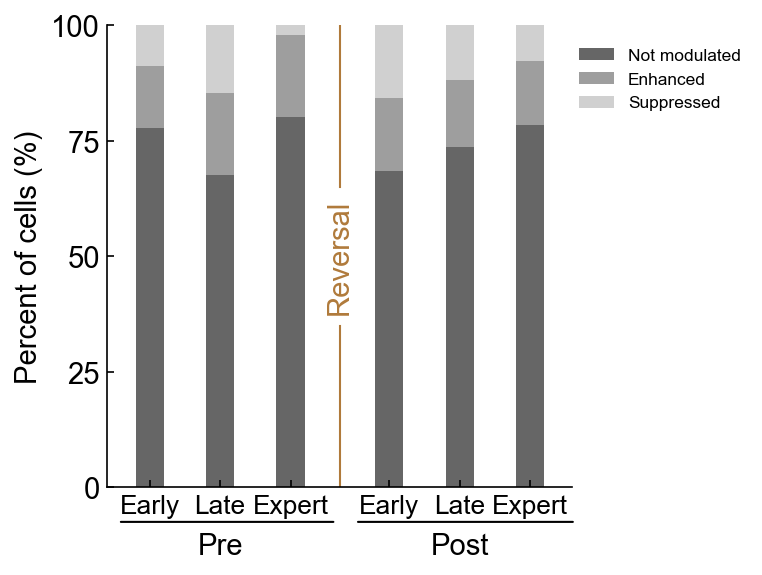

In [9]:
fig,ax = plt.subplots(figsize=(4,4))

wid = 0.4
lw=1.5
offset = 0.2
x_points = np.array(range(6)) + [-offset,-offset,-offset,offset,offset,offset]
# plt.bar(x_points,ns_list,width=wid,fc='#ff937e',label='n.s.',lw=lw)
# plt.bar(x_points,en_list,bottom=ns_list,width=wid,fc=CR_COLOR,ec='#7ff0ff',label='enhanced',lw=lw)
# plt.bar(x_points,su_list,bottom=ns_list+en_list,width=wid,fc=CR_COLOR,ec='#a0da86',label='suppressed',lw=lw)

plt.bar(x_points,ns_list,width=wid,fc='k',label='Not modulated',lw=lw,alpha=0.6)
plt.bar(x_points,en_list,bottom=ns_list,width=wid,fc='#5D5D5D',label='Enhanced',lw=lw,alpha=0.6)
plt.bar(x_points,su_list,bottom=ns_list+en_list,width=wid,fc='#B1B1B1',label='Suppressed',lw=lw,alpha=0.6)
#Previous color: '#7e88ff'

ax.set_xlim([-0.8,5.8])
ax.set_xticks(x_points)
labels = ['Early','Late','Expert','Early','Late','Expert']
ax.set_xticklabels(labels)

stdfont = 14
stdyfrac = 0.075
xtick_pos_pre = ax.get_xticks()[1]
xtick_pos_post = ax.get_xticks()[4]
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac,log=False)
t1 = ax.text(xtick_pos_pre, Yval, 'Pre', ha='center', va='bottom', fontsize=stdfont,color='k')
t2 = ax.text(xtick_pos_post, Yval, 'Post', ha='center', va='bottom',  fontsize=stdfont,color='k')
ax.annotate('', xy=(0.02, -stdyfrac), xycoords='axes fraction', xytext=(0.495, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(0.53, -stdyfrac), xycoords='axes fraction', xytext=(1.01, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.set_ylim([0,1])
ax.set_yticks([0,0.25,0.5,0.75,1])
ax.set_yticklabels(['0','25','50','75','100'])
ylab = ax.set_ylabel('Percent of cells (%)')

Y = np.mean(ax.get_ylim())
Y = np.mean((ax.get_ylim()))
t = ax.text(2.5,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
ax.plot([2.5]*2,[ax.get_ylim()[0],Y-0.15],lw=1,color=SWITCH_COLOR)
ax.plot([2.5]*2,[ax.get_ylim()[1],Y+0.15],lw=1,color=SWITCH_COLOR)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass

leg=ax.legend(frameon=False,loc=(1.0,0.8))
artists = [ylab,t1,t2,leg]
# fig.savefig(os.path.join('C:\\Users\\abrah\\Documents\\Revision Figs\\Figure 2\\Go Nogo response summary_v3.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')